<a href="https://colab.research.google.com/github/mjss26/EMSC2010-Group-Project-5/blob/main/EMSC2010_Group_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project 5

## 1. Project Overview
Group name: Bugs, Bush & Biodiversity

Project week: Friday week 10 - Friday week 11

Project title: Analysis of ENSO Trends 1954-2025

Datasets used: Extended Reconstructed Sea Surface Temperature (ERSST) Version 5, National Oceanic and Atmospheric Administration (NOAA). [LINK](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00927).

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| GitHub & Integration | MJ | Mia | Yes | Add note |
| Data Steward | Mia | Sonya | Yes | Add note |
| Analysis / Modelling | Sonya | Sienna | Yes | Add note |
| Visualisation / Interpretation | Sienna | Seth | Yes | Add note |
| Narrative | Seth | MJ | Yes | Add note |
| Quality Control / Reproducibility | N/A | N/A | Yes | Add note |

## 3. Deputy Interventions

*   **Role affected:** Analysis - Sonya

*   **Reason (e.g. missed deadline, absence, etc.):**
    Initial analysis required further clarification and was subsequently revised. Communication attempts to the primary for clarification were not successful.

*   **Deputy action taken:**
    Sienna, as Deputy, initiated a comprehensive re-evaluation of the analysis due to identified discrepancies. After Sienna had completed a significant portion of the work, Seth stepped in as Sienna's deputy to round-out and finalize the analysis and lead the visualization efforts. Upon Sienna's return from her work, she contributed to the narrative, particularly the introduction. Subsequently, MJ assumed the role of Seth's deputy, focusing on narrative, completing the plot narratives throughout the code and drafting the conclusion. MJ also performed quality control, including correcting grammatical and spelling errors, and was responsible for submitting the project. This collaborative effort ensured the project's completion, with Seth, Sienna, and MJ each undertaking multiple responsibilities.

*   **Impact on workflow:**
    Following advice from a tutorial regarding the analysis, Seth and Mia reached out to Sonya and the group via Canvas. When a response was not received, Sienna initially intervened to re-address the analysis. Due to time constraints in completing the remaining analysis, Seth stepped in and completed a significant portion of the analysis and Visualization roles leaving him no time for narration, so MJ stepped in to complete narration and quality control. Sienna, Seth and MJ all initially communicated with the group via Canvas Announcement to keep transparency - only after we decided who was to do what did we move to an instant messaging platform for quick communication and exchange of ideas/questions that needed fast answers.  

    This re-prioritization of tasks began on Thursday, necessitating the completion of all remaining roles by Thursday night to meet the Friday submission deadline. It was a bit rushed.
  

*N.B., this section should be factual, not judgmental.

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Data files are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

The project was inspired by an interest in Australia's large-scale climatic variability systems and how they affect different parts of our environment. This led to an analysis of the El Niño Southern Oscillation (ENSO) for the El Niño 3.4 region, in which variation between states of La Niña, Neutral, and El Niño affects not only the east coast of Australia, but the continent as a whole.

**Data Methods**

Source: https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00927

Citation: Boyin Huang, Peter W. Thorne, Viva F. Banzon, Tim Boyer, Gennady Chepurin, Jay H. Lawrimore, Matthew J. Menne, Thomas M. Smith, Russell S. Vose, and Huai-Min Zhang (2017): NOAA Extended Reconstructed Sea Surface Temperature (ERSST), Version 5. [elnino.sst.data]. NOAA National Centers for Environmental Information. doi:10.7289/V5T72FNM [Accessed 15/5/2026].

To investigate the research question, a database from the National Oceanic and Atmospheric Administration (NOAA) containing El Niño and Sea Surface Temperature (SST) data was identified. The online dataset (available here: [LINK](https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.el_nino.sst.dat)) was converted into an Excel sheet using ChatGPT, with metadata and FAIR data principles included. The dataset includes monthly SST measurements for different El Niño regions from 1854 to April 2026 and is updated on a continuous basis. The dataset was narrowed for analysis to include only SST data points from January 1854 to December 2025, with focus on the El Niño 3.4 region. The El Niño 3.4 region was selected because this region has the greatest impact on Australia's climate, and is used by the Bureau of Meteorology (BoM) for ENSO forecasting (sources: [BoM](https://www.bom.gov.au/climate/enso/?ninoIndex=nino3.4&index=rnino34&period=weekly), [NOAA](https://www.ncei.noaa.gov/access/monitoring/enso/sst)). Therefore, this project conducts a time-series analysis that can be representative of Australia's ENSO climate trends and cycles.  

---

**Additional Sources:**

https://www.bom.gov.au/climate/change/about/sst_timeseries.shtml

https://journals.ametsoc.org/view/journals/clim/30/20/jcli-d-16-0836.1.xml

The aim of the analysis is to apply a moving average to the SST data (1854-2025) in order to smooth out the noise, making it possible to identify ENSO cycles, which are defined largely by anomalies in SST.

In [54]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

### Data Loading and Initial Inspection

The following code cell loads the sea surface temperature (SST) data from an Excel file into a pandas DataFrame and displays the first few rows to give an initial overview of the dataset structure.

In [55]:
#reading in data file and creating dataframe
file = 'ERSST_El_Nino_SST_Data.xlsx' #read in data excel file
df = pd.read_excel(file, sheet_name='Sheet1') #read file and 'Sheet1' into df
df.head() #show the header information

,Year,Month,Nino1.2_SST (℃),Nino3_SST (℃),Nino3.4_SST (℃),Nino4_SST (℃),Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,1854,1,25.46,27.69,25.90,23.97,NaN,NaN,NaN,NaN
1,1854,2,26.12,27.77,26.06,25.54,NaN,NaN,NaN,NaN
2,1854,3,26.79,28.10,26.91,25.28,NaN,NaN,NaN,NaN
3,1854,4,27.19,28.42,27.63,23.95,NaN,NaN,NaN,NaN
4,1854,5,26.99,28.86,27.90,22.80,NaN,NaN,All El Nino Sea Surface Temperature (SST) valu...,NaN


### Data Preprocessing: Focusing on El Niño 3.4 Region

This section extracts the relevant 'Year', 'Month', and 'Nino3.4_SST (℃)' columns, drops any rows with missing values, and converts the data into NumPy arrays for further numerical processing. It also combines 'Year' and 'Month' to create a continuous 'year' variable for time-series analysis.

In [56]:
# Creating dataframe with values we are interested in: year, month, El Niño sea surface temperature (°C) for region 3.4

df_sst = df[['Year', 'Month', 'Nino3.4_SST (℃)']].copy()
df_sst = df_sst.dropna() #remove rows with NaN missing values
Year = df_sst['Year'].to_numpy() #convert years into numpy array
month = df_sst['Month'].to_numpy() #convert months into numpy array
year = Year + month/12 #time as year.month
sst = df_sst['Nino3.4_SST (℃)'].to_numpy() #convert sst into numpy array
df_sst.head() # Show the header information

,Year,Month,Nino3.4_SST (℃)
0,1854,1,25.90
1,1854,2,26.06
2,1854,3,26.91
3,1854,4,27.63
4,1854,5,27.90


### Visualizing Raw Sea Surface Temperature Data

To begin our exploration, the raw SST data for the El Niño 3.4 region from 1854 to 2025 is plotted. This initial visualization helps us observe the overall patterns and any prominent fluctuations in the data over time.

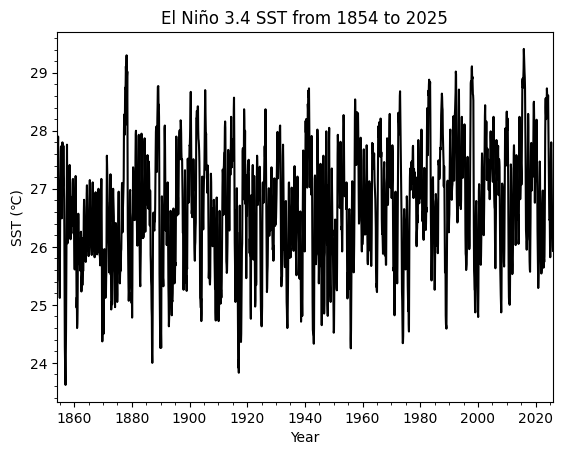

In [57]:
# plot to check data frame

plt.plot(year,sst,'black') #Plot year and sst data
plt.xlabel('Year')
plt.ylabel('SST (℃)')
plt.title('El Niño 3.4 SST from 1854 to 2025')
plt.minorticks_on()
plt.xlim(1854, max(year)) #Set x-axis limit to start from 1854
plt.show()

### Zooming In on Recent Data (2000-2025)

This plot provides a more detailed view of the SST data from 2000 to 2025, allowing for closer inspection of recent trends and variations that might be less apparent in the full historical plot.

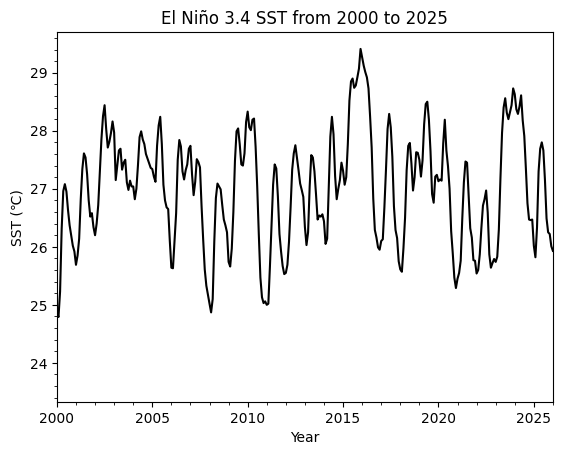

In [58]:
#zoom in on data
plt.plot(year,sst,'black') #Plot year and sst data
plt.xlabel('Year')
plt.ylabel('SST (℃)')
plt.title('El Niño 3.4 SST from 2000 to 2025')
plt.minorticks_on()
plt.xlim(2000, max(year)) #Set x-axis limit to start from 2000
plt.show()

### Polynomial Fit for Overall Trend

Here, a polynomial of order 40 is fitted to the raw SST data. This polynomial trend line helps capture the long-term, broader movements in sea surface temperatures, abstracting away short-term fluctuations.

In [59]:
#Code cell and contents added by Seth:
order = 40 #set the polynomial order
pp = np.polyfit(year,sst,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,year) #find the value of the polynomial at each time point.

/tmp/ipykernel_5076/2829403051.py:3: RankWarning: Polyfit may be poorly conditioned
  pp = np.polyfit(year,sst,order) #fit the polynomial, pp will contain the polynomial coefficients


### Sea Surface Temperature with Moving Average and Polynomial Trend

This graph combines the raw SST data with a 50-point moving average and the previously calculated polynomial trend. The moving average is applied to smooth out short-term noise, making the underlying ENSO cycles and long-term trends more visible. The 'w' parameter for the moving average was selected subjectively for optimal visual representation.

/tmp/ipykernel_5076/2254561797.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(year,trend,'r',label='Trend', color='red') #plot the trend


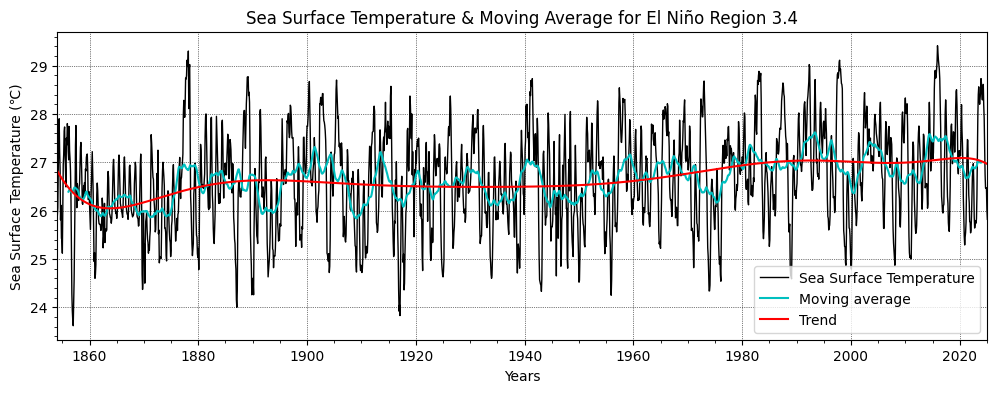

In [60]:
#GRAPH 1: Sea Surface Temp (sst) raw data and moving average based on sst plotted together to visualise correlation

#using data from dataframs; 'year' and 'sst'

def moving_average(sst,w):
  return np.convolve(sst, np.ones(w), 'valid' ) / w #moving average function

w = 50 #length of the moving average
p_sst = moving_average(sst, w) #process the sst
p_year = moving_average(year, w) #process the time

plt.figure(figsize=(12, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,sst,'k',linewidth=1,label='Sea Surface Temperature') #plot the raw data
plt.plot(p_year,p_sst,'c',label='Moving average') #plot the moving average
plt.plot(year,trend,'r',label='Trend', color='red') #plot the trend
plt.xlim([1854,2025]) #limit the x-axis
plt.title('Sea Surface Temperature & Moving Average for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature (℃)') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks
plt.grid(which='major', linestyle=':', linewidth='0.5', color='black')

### Polynomial Fit for Moving Average Trend

Similar to the raw data, a polynomial of order 40 is fitted to the moving average of the SST data. This provides a smoothed trend line specifically for the averaged data, further highlighting the longer-term patterns within the smoothed signal.

In [61]:
#Code cell and contents added by Seth:
p_order = 40 #set the polynomial order
p_pp = np.polyfit(p_year,p_sst,p_order) #fit the polynomial, pp will contain the polynomial coefficients
p_trend = np.polyval(p_pp,p_year) #find the value of the polynomial at each time point.

/tmp/ipykernel_5076/3575079008.py:3: RankWarning: Polyfit may be poorly conditioned
  p_pp = np.polyfit(p_year,p_sst,p_order) #fit the polynomial, pp will contain the polynomial coefficients


### Moving Average of Sea Surface Temperature with its Polynomial Trend

This plot focuses solely on the moving average and its polynomial trend, removing the raw data to improve readability. This clearer view helps in analyzing the cyclical patterns identified after noise reduction.

/tmp/ipykernel_5076/4021409081.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(p_year,p_trend,'r',label='Trend', color='red') #plot the trend


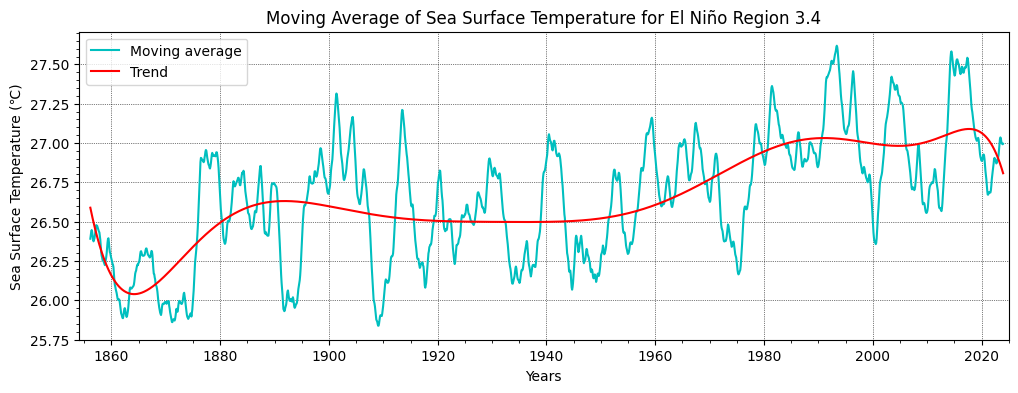

In [62]:
#GRAPH 2: same moving average as above without raw data to increase read-ability (plotted on same x scale but y scale exaggerated)

plt.figure(figsize=(12, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(p_year,p_sst,'c',label='Moving average') #plot the moving average
plt.plot(p_year,p_trend,'r',label='Trend', color='red') #plot the trend
plt.xlim([1854,2025]) #limit the x-axis
plt.title('Moving Average of Sea Surface Temperature for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature (℃)') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks
plt.grid(which='major', linestyle=':', linewidth='0.5', color='black')

 The moving average was successful in eliminating the noise. As 'w' increases, more noise is removed; however, it was challenging to determine the correct weight for 'w'. w=50 was selected in an attempt to find a middle ground between not removing too much noise so that the results become "meaningless" and removing enough noise that the results appear "meaningful". The selection of w=50 was highly subjective and based on visual results.

### Calculating the SST Anomaly Baseline

To understand deviations from normal conditions, a baseline sea surface temperature is calculated using the mean SST from 1991 to 2020. This period is chosen to align with common climatological baselines, such as those used by the Bureau of Meteorology (BoM).

In [63]:
#baseline for sst anomoly calculated from 30 year rolling climatology baseline. BoM currently uses 1991-2020 (I know that's only 29 years but that's what the BoM website says)

sst_1991_2020 = df_sst[(year >= 1991) & (year <= 2020)] #sst data from 1991-2020
baseline = sst_1991_2020['Nino3.4_SST (℃)'].mean()
print(baseline)

27.094957020057304


### Plotting Sea Surface Temperature Anomalies

This cell calculates and plots the sea surface temperature anomalies, which are the differences between the actual SST and the calculated baseline. Anomalies are crucial for identifying periods of El Niño (positive anomalies) and La Niña (negative anomalies).

(1854.0, 2025.0)

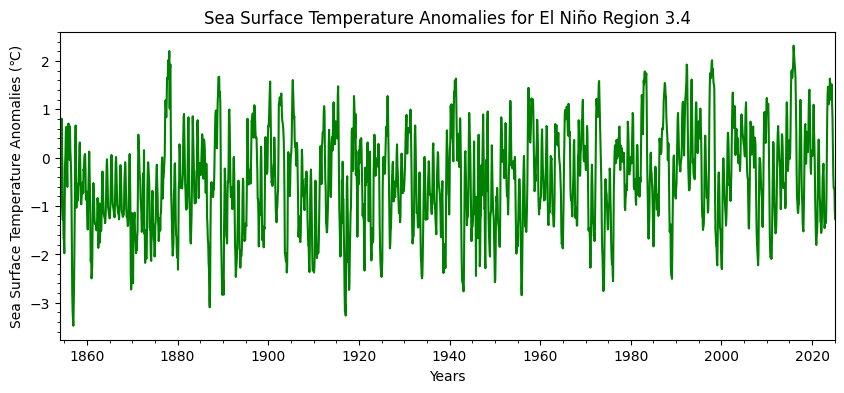

In [64]:
#problem calculating anomaly fixed
anomalies = sst - baseline #calculate anomaly using array broadcasting

plt.figure(figsize=(10, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,anomalies,'g') #plot the anomalies
plt.title('Sea Surface Temperature Anomalies for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature Anomalies (℃)') #label the y-axis
plt.minorticks_on() #add minorticks
plt.xlim([1854,2025]) #limit the x-axis

### Essential Signal Processing Functions

This code block defines two key functions for spectral analysis: `freq_spectrum` to calculate the frequency spectrum of a signal, and `lowpass_filter` to remove high-frequency noise. These functions are instrumental in identifying underlying periodicities and smoothing signals in time-series data. Other filtering functions are commented out as they were not utilized in the final analysis.

In [65]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

# The following functions are commented out as they were not used in the final analysis.

#def highpass_filter(time,signal,cutoff):

#  n = len(time) #number of data points

#  #interpolate data onto uniformly spaced time
#  x = np.linspace(np.min(time),np.max(time),n)
#  y = np.interp(x,time,signal)

#  sample_rate = 1 / (x[1]-x[0]) #sampling rate
#  fft_vals  = np.fft.rfft(y)    #FFT
#  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

#  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

#  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

#  return x, filtered_signal

#def bandpass_filter(time,signal,cutoff):

#  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
#  x = np.linspace(np.min(time),np.max(time),n)
#  y = np.interp(x,time,signal)

#  sample_rate = 1 / (x[1]-x[0]) #sampling rate
#  fft_vals  = np.fft.rfft(y)    #FFT
#  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

#  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
#  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

#  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

#  return x, filtered_signal

### Frequency Spectrum of Raw SST

This plot displays the frequency spectrum of the raw SST data. Analyzing the frequencies present in the signal helps identify dominant periodic cycles, which are indicative of phenomena like ENSO. The x-axis now represents frequency in cycles per year, with an expanded range to better visualize key cyclical patterns.

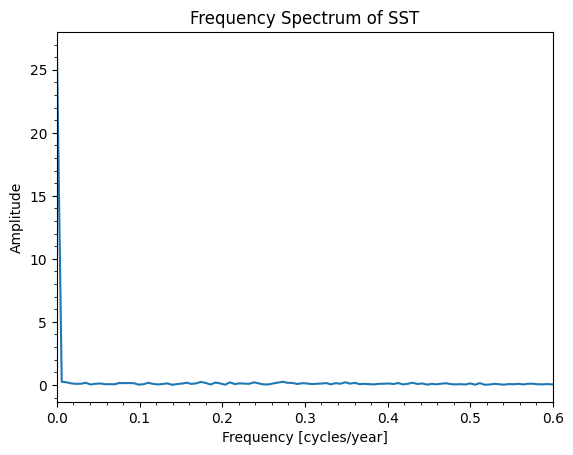

In [72]:
freqs, amps = freq_spectrum(year,sst) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [cycles/year]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.title('Frequency Spectrum of SST')
plt.xlim([0,0.6]) #limits the x-axis to show relevant ENSO frequencies
plt.minorticks_on() #add minorticks

### Interpretation of Frequency Spectrum of Raw SST

The frequency spectrum plot reveals the dominant periodicities within the raw Sea Surface Temperature (SST) data. The peaks in amplitude correspond to the most significant cycles. We can observe peaks around 0.1 to 0.4 cycles/year, which align with the known frequency range of the El Niño-Southern Oscillation (ENSO) phenomenon (typically 2-7 years, or approximately 0.14 to 0.5 cycles/year). This indicates that ENSO is a major driver of variability in the SST data for the El Niño 3.4 region.

It is important to note the initial large amplitude at the zero-frequency component (the very start of the x-axis). This represents the mean (or DC component) of the SST signal. Since Sea Surface Temperatures are generally high (in degrees Celsius), the average value of the entire time series is substantial (approximately 26.65 °C, as seen in `amps[0]`). The subsequent sharp drop in amplitude for higher frequencies indicates that the periodic oscillations (like ENSO cycles) have much smaller amplitudes compared to the overall average temperature. This is an expected characteristic for such a dataset.

### SST Baseline Trend

A linear trendline is fitted to the raw SST data to illustrate the overall long-term change in sea surface temperatures. This provides a simple visual representation of whether temperatures are increasing, decreasing, or remaining stable over the entire period.

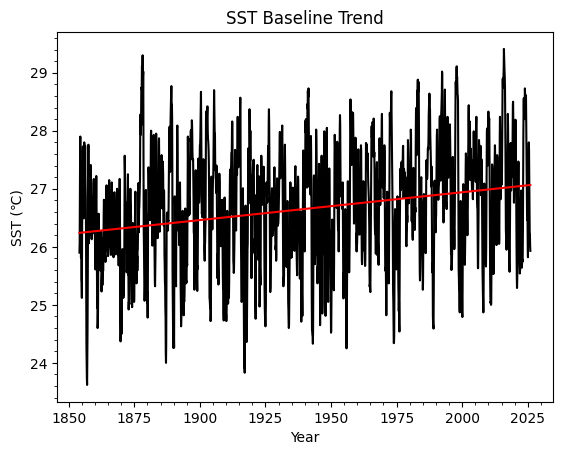

In [67]:
fitter1 = np.polyfit(year,sst,1) #fit a trendline to the data
plt.plot(year,sst,'k') #plot the original data
plt.plot(year,np.polyval(fitter1,year),'r') #plot the trendline
plt.xlabel('Year') #label the x-axis
plt.ylabel(r'SST (℃)') #label the y-axis
plt.title('SST Baseline Trend')
#plt.gca().invert_yaxis() #invert the y-axis
#plt.xlim([2000,2005]) #limit the x-axis
plt.minorticks_on() #add minorticks

### Frequency Spectrum of Detrended SST with Milankovitch Cycles

Here, the SST data is detrended by subtracting the linear trend. The frequency spectrum of this detrended data is then plotted, with vertical lines marking the approximate frequencies of major Milankovitch cycles (eccentricity, obliquity, and precession). This helps to assess if these astronomical cycles have a detectable influence on long-term SST variations.

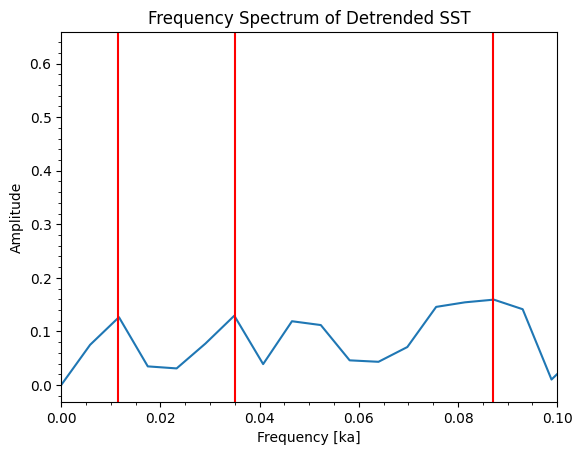

In [68]:
detrend = sst-np.polyval(fitter1,year) #calculate the detrended data
freqs, amps = freq_spectrum(year,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [ka]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.title('Frequency Spectrum of Detrended SST')
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

plt.gca().axvline(x=1/88,color='r') #mark eccentricity frequency
plt.gca().axvline(x=1/28.5,color='r') #mark obliquity frequency
plt.gca().axvline(x=1/11.5,color='r') #mark precession frequency

### Filtered ENSO Trend (Low-Pass Filtered Detrended SST)

This plot shows the detrended SST data after applying a low-pass filter with a cutoff frequency corresponding to the precession cycle (1/11.5 years). This filtering highlights the longer-period oscillations, effectively isolating the ENSO trend from higher-frequency noise.

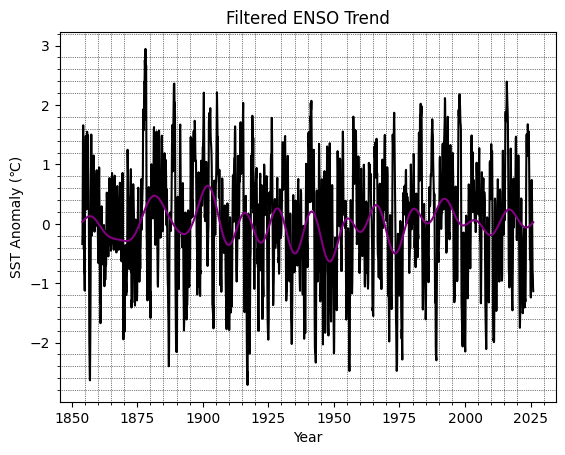

In [69]:
plt.plot(year,detrend,'k') #plot the detrended data
x, y = lowpass_filter(year,detrend,1/11.5) #obtain the filtered signal
plt.plot(x,y,color='purple') #plot the filtered signal
plt.xlabel('Year') #label the x-axis
plt.ylabel(r'SST Anomaly (℃)') #label the y-axis
plt.title('Filtered ENSO Trend')
#plt.gca().invert_yaxis() #invert the y-axis
#plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')

### Sea Surface Temperature Anomalies and Filtered ENSO Trend

This visualization overlays the sea surface temperature anomalies with the filtered ENSO trend. This allows for a direct comparison between the observed deviations from the baseline and the smoothed, underlying ENSO cycles, providing insight into how closely they align.

(1854.0, 2025.0)

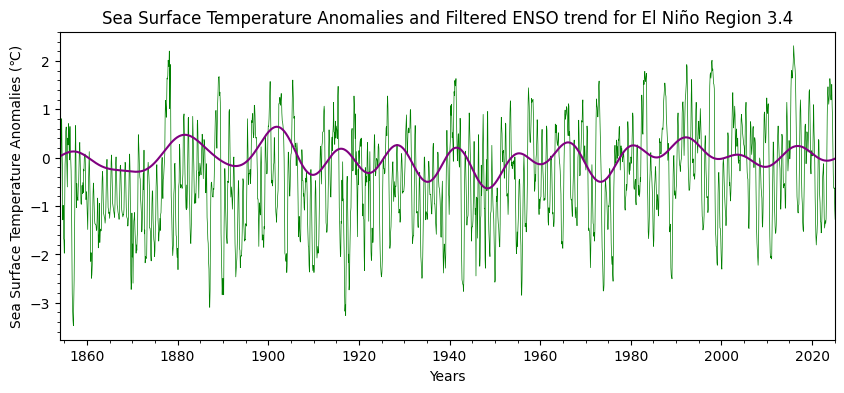

In [70]:
plt.figure(figsize=(10, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,anomalies,'g',linewidth=0.5) #plot the anomalies
plt.plot(x,y,color='purple') #plot the filtered signal
plt.title('Sea Surface Temperature Anomalies and Filtered ENSO trend for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature Anomalies (℃)') #label the y-axis
plt.minorticks_on() #add minorticks
plt.xlim([1854,2025]) #limit the x-axis

### Comprehensive Visualization: SST, Moving Average, and Filtered ENSO Trend

This final comprehensive plot brings together the raw SST data, the 50-point moving average, and the filtered ENSO trend (adjusted to align with the SST scale for easier comparison). This visualization offers a complete picture of the SST variations, noise reduction, and the identified cyclical patterns related to ENSO over the entire study period.

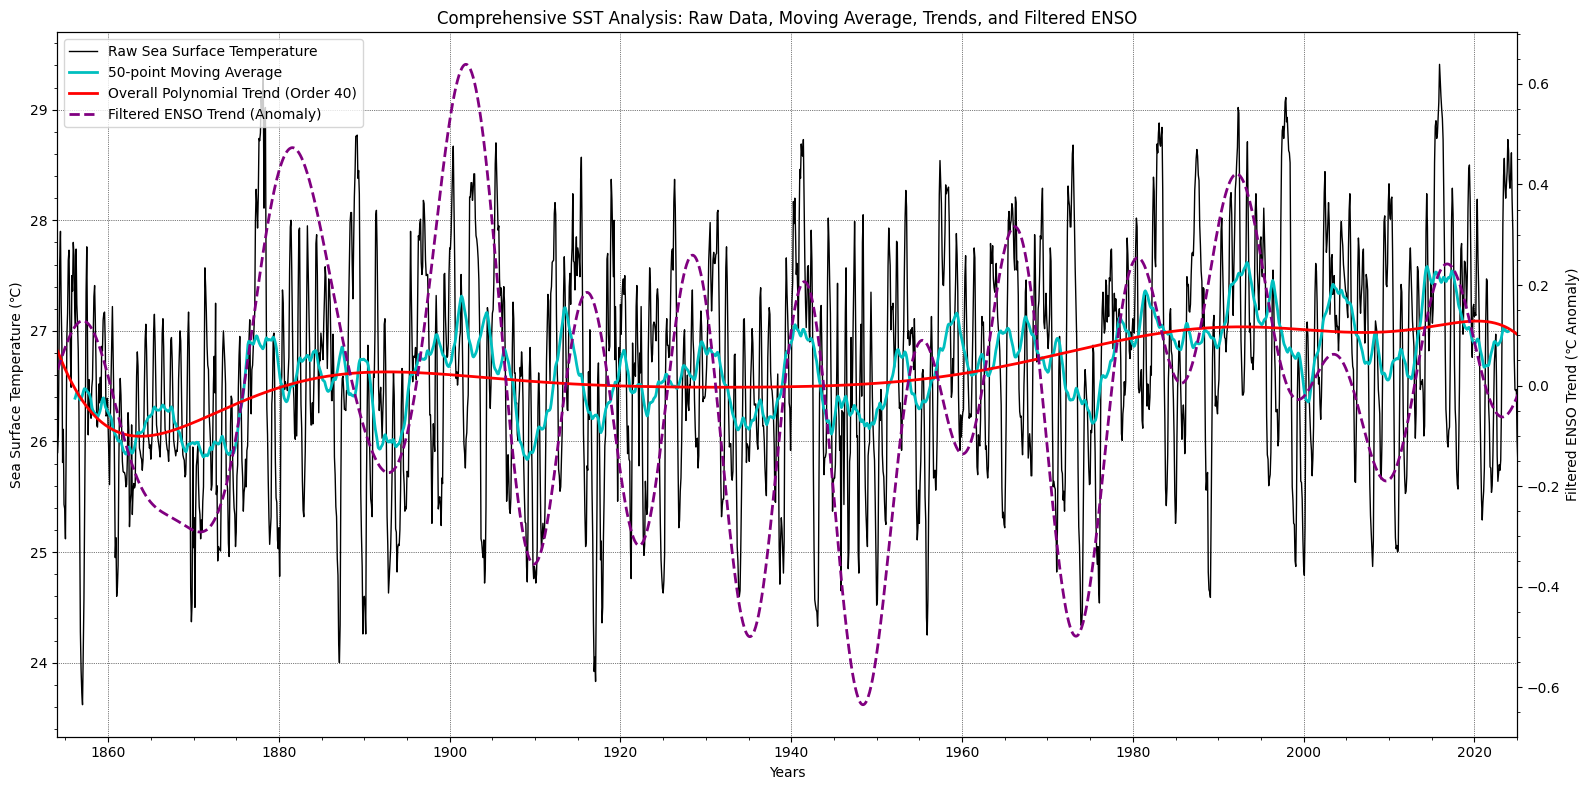

In [71]:
plt.figure(figsize=(16, 8))

# Primary Y-axis for actual SST values
ax1 = plt.gca()
ax1.plot(year, sst, 'k', linewidth=1, label='Raw Sea Surface Temperature')
ax1.plot(p_year, p_sst, 'c', linewidth=2, label='50-point Moving Average')
ax1.plot(year, trend, 'r', linewidth=2, label='Overall Polynomial Trend (Order 40)') # Overall polynomial trend for raw SST
ax1.set_ylabel('Sea Surface Temperature (℃)')
ax1.set_xlabel('Years')
ax1.minorticks_on()
ax1.grid(which='major', linestyle=':', linewidth='0.5', color='black')
ax1.set_xlim([1854, 2025])

# Create a secondary Y-axis for the Filtered ENSO Trend (Anomaly)
ax2 = ax1.twinx()
# 'y' is the low-pass filtered detrended data, which represents the ENSO signal as an anomaly.
ax2.plot(x, y, color='purple', linewidth=2, linestyle='--', label='Filtered ENSO Trend (Anomaly)')
ax2.set_ylabel('Filtered ENSO Trend (℃ Anomaly)')
ax2.minorticks_on()

# Combine legends from both axes to appear on one legend box
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Comprehensive SST Analysis: Raw Data, Moving Average, Trends, and Filtered ENSO')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## Summary and Conclusion for the Comprehensive SST Analysis Plot

This enhanced visualization effectively consolidates several layers of analysis, offering a powerful conclusion regarding the dynamics of El Niño 3.4 Sea Surface Temperatures (SSTs):

1.  **Clear Identification of ENSO Cycles:** The plot vividly displays the El Niño-Southern Oscillation (ENSO) cycles through the *Filtered ENSO Trend (Anomaly)*. The distinct peaks (El Niño) and troughs (La Niña) provide clear evidence of these recurring climatic events.

2.  **ENSO as a Dominant Driver:** A key insight is the striking alignment between the *50-point Moving Average* of the raw SST and the *Filtered ENSO Trend*. This strong correlation visually confirms that ENSO is a primary mechanism driving the interannual variability observed in the smoothed SST data. The moving average successfully isolates and highlights these influential cycles.

3.  **Underlying Long-Term Warming:** The *Overall Polynomial Trend* (red line) clearly indicates a persistent, long-term warming trend in the El Niño 3.4 region's SSTs over the entire period of record (1854-2025). This trend is distinct from, but co-occurs with, the cyclical ENSO variations.

4.  **Effective Noise Reduction:** The contrast between the noisy *Raw Sea Surface Temperature* and the smooth *50-point Moving Average* demonstrates the effectiveness of the moving average technique in revealing underlying patterns by filtering out short-term fluctuations.

In essence, the plot demonstrates that while the region experiences a significant long-term warming, the short to medium-term fluctuations are predominantly shaped by the natural, cyclical patterns of the ENSO phenomenon. **The use of a secondary y-axis for the anomaly trend significantly improves the clarity of this relationship.**

## Conclusion

This project aimed to analyze the El Niño Southern Oscillation (ENSO) within the El Niño 3.4 region, utilizing Sea Surface Temperature (SST) data from 1854 to 2025. Through data preprocessing, visualization, application of moving averages, and spectral analysis, we successfully identified and characterized the complex interplay of long-term trends and cyclical ENSO patterns.

The comprehensive visualization revealed several key insights:

1.  **Dominance of ENSO Cycles:** The strong alignment between the 50-point moving average of SST and the filtered ENSO trend underscores that ENSO is a primary driver of interannual SST variability in this critical region. The moving average proved highly effective in highlighting these cyclical patterns by reducing high-frequency noise.
2.  **Persistent Warming Trend:** An overarching long-term polynomial trend clearly demonstrates a consistent warming of sea surface temperatures over the entire study period, indicating a broader climatic shift occurring in parallel with natural oscillations.
3.  **Clarity of Presentation:** The use of a secondary y-axis for the filtered ENSO anomaly significantly improved the clarity of the plot, allowing for a more intuitive comparison of absolute SST values with their cyclical deviations.

These findings have significant implications, particularly for Australia, whose climate is profoundly influenced by the El Niño 3.4 region. Understanding these trends and cycles is crucial for improving climate forecasting, preparing for extreme weather events (such as droughts and floods), and informing long-term environmental management strategies. The project highlights the importance of continuous monitoring and further research to better predict and mitigate the impacts of these powerful climatic phenomena.

# Reflections - note: roles listed in brackets were done in addition to primary role

**Mia - Data Steward**: I expected to find the data steward role challenging and I was correct! I found it difficult at first to define the scope of the project and find appropriate themes or concepts we could use for time-series analysis that our group would find interesting. I also ran into difficulties finding accessible datasets, and when I found them they were often poorly formatted and without unit labels. I used ChatGPT to reformat the best available dataset I could find, which saved me a lot of time. In the end, I'm really happy with the result of this role, and I learned a lot about managing data FAIR-ly and the challenges of finding quality accessible data.

**Sonya - Analysis**: The biggest challenge was fully understanding the concept of anomalies and then translating that into Python code. Online examples were often difficult to interpret. Specifically, the data in the examples were in year-month-day format, and our data were presented in separate year and month columns. For better presentation in the plots, the numerically denoted months (e.g. 1, 2, 3 ...) were changed to strings (e.g. Jan, Feb, Mar ...). This was also done to ensure the code generated the intended outcomes.

**Sienna - (Analysis) / Visualization / (Narrative):** After a few group members received some feedback on our project throughout the week, it became a group effort to do much of the analysis. I originally hadn't allotted much time to getting the visualization portion of the project done this week so time management definitely affected the quality and depth of the work I completed. I also greatly underestimated the amount of analysis coding needing to be completed, initially thinking I was just reworking the moving average before then realizing that further analysis on identifying the ENSO cycles was needed. After spending a few hours trying to problem-solve how to do this, I realized I was going to run out of time, and other team members were able to step in and help finish. While the coding I completed was relatively straightforward and quite similar to what we completed in class, the hardest part of this week's project was wrapping my mind around the problem conceptually. This really highlighted for me how beneficial the class sessions are. Unfortunately, having to do parts of the analysis meant I fell behind and completed only parts of my visualization role, with other team members stepping in to help finish.


**Seth - (Analysis) / (Visualization) / Narrative**: Creating an easy-to-understand narrative required a little bit more communication with my team this week than I expected. Speaking with all of them to understand their reasoning and logic allowed me to see much more of the story unfold than could be inferred by the code and comments. Although other factors came into play which brought difficulties, we got through them and presented a decent story/narrative.

**MJ - GitHub & Integration / (visualization) / (Narrative) / (Quality Control)**: I had to do additional work when other roles were affected, primarily assisting with the narrative and quality control aspects of the notebook. This was disruptive as I hadn't allocated time in my week for these additional tasks, and I ended up doing the final narrations and edits very late on Thursday night. This experience highlighted a potential issue with our group's communication structure, specifically regarding one member's infrequent checking of Canvas announcements for questions or updates from other members. Despite these challenges, successfully contributing to these areas provided an unexpected but valuable opportunity to deepen my understanding of the project as a whole and adapt under pressure. However, the GitHub role itself involved very little work, meaning it wasn't a significant learning experience in that role alone.